## Example 3b (One-Sample T-Test, Two-Tailed, 80% Confidence Interval)

Same problem as the [95% CI notebook](12_Hypothesis_Testing_T-Test_95.ipynb) — only the confidence level changes. In the population, the average **IQ is 100**. A team of researchers wants to test a new medication to see if it has either a **positive or negative** effect on intelligence, or **no effect at all**. A sample of **30 participants** who have taken the medication has a mean of **140**, with a standard deviation of **20**. Did the medication affect intelligence? (**CI = 80%**)

**Given:**
- $\mu = 100$ (population mean IQ)
- $n = 30$ (sample size)
- $\bar{x} = 140$ (sample mean)
- $S = 20$ (sample std)
- $CI = 80\%$

Because the researchers are checking for **either** a positive **or** a negative effect (not specifically one direction), this is still a **two-tailed test** — only $CI$ (and therefore $\alpha$ and the critical value) changes.

### Step 1 - State the Null and Alternate Hypothesis

$$H_0: \mu = 100$$
$$H_1: \mu \neq 100 \quad \text{(two-tailed test)}$$

The hypotheses themselves **never depend on the confidence level** — they come purely from the wording of the question ("positive or negative effect, or no effect"). Only the *threshold* for deciding changes when $CI$ changes.

### Step 2 - Significance Value

$$CI = 80\% = 0.80$$
$$\alpha = 1 - CI = 1 - 0.80 = 0.20$$

This time we're only willing to be **80% confident**, so we tolerate a bigger risk of a Type I error: $\alpha = 0.20$ instead of $0.05$. Split evenly across both tails (two-tailed test):

$$\dfrac{\alpha}{2} = \dfrac{0.20}{2} = 0.10 \text{ on each side}$$

Compare this to the 95% CI case, where $\alpha/2$ was only $0.025$ — a lower confidence level means a **wider, more lenient** rejection region on each side.

### Step 3 - Degrees of Freedom

$$df = n - 1 = 30 - 1 = 29$$

`df` only depends on the sample size, not on the chosen confidence level — so this is identical to the 95% CI case.

In [1]:
import scipy.stats as st
import numpy as np
import matplotlib.pyplot as plt

### Step 4 - Decision Boundary

Look up the t-table at **df = 29**, two-tailed $\alpha = 0.20$ (i.e. 0.10 in each tail):

$$t_{critical} \approx \pm 1.311$$

The region between $-1.311$ and $+1.311$ is the **acceptance region** (fail to reject $H_0$). Anything beyond that, in either tail, is the **rejection region** (reject $H_0$).

Notice how much **narrower** this acceptance region is compared to the 95% CI case ($\pm 2.045$) — at a lower confidence level, we require *less* evidence before rejecting $H_0$.

**Decision rule:** If $t_{test} < -1.311$ or $t_{test} > 1.311$, reject the null hypothesis.

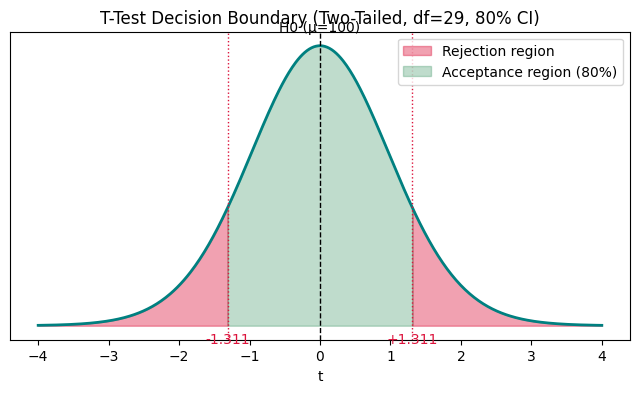

In [2]:
df = 29
alpha = 0.20

t_crit = st.t.ppf(1 - alpha / 2, df)   # ~1.311

x = np.linspace(-4, 4, 500)
y = st.t.pdf(x, df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, color="teal", linewidth=2)

# rejection regions - both tails
x_left = np.linspace(-4, -t_crit, 100)
x_right = np.linspace(t_crit, 4, 100)
ax.fill_between(x_left, st.t.pdf(x_left, df), color="crimson", alpha=0.4, label="Rejection region")
ax.fill_between(x_right, st.t.pdf(x_right, df), color="crimson", alpha=0.4)

# acceptance region
x_mid = np.linspace(-t_crit, t_crit, 200)
ax.fill_between(x_mid, st.t.pdf(x_mid, df), color="seagreen", alpha=0.3, label="Acceptance region (80%)")

ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.text(0, max(y) * 1.05, "H0 (μ=100)", ha="center")
ax.axvline(-t_crit, color="crimson", linestyle=":", linewidth=1)
ax.axvline(t_crit, color="crimson", linestyle=":", linewidth=1)
ax.text(-t_crit, -0.01, f"-{t_crit:.3f}", ha="center", va="top", color="crimson")
ax.text(t_crit, -0.01, f"+{t_crit:.3f}", ha="center", va="top", color="crimson")

ax.legend()
ax.set_yticks([])
ax.set_xlabel("t")
ax.set_title(f"T-Test Decision Boundary (Two-Tailed, df={df}, 80% CI)")
plt.show()

### Step 5 - Calculate the T-Test Statistic

$$t_{test} = \dfrac{\bar{x} - \mu}{\dfrac{S}{\sqrt{n}}} = \dfrac{140 - 100}{\dfrac{20}{\sqrt{30}}} = \dfrac{40}{3.65} \approx 10.96$$

This step is **completely unaffected** by the confidence level — $t_{test}$ only depends on the sample data ($\bar{x}, \mu, S, n$), never on $\alpha$ or $CI$. Only $t_{critical}$ (Step 4) changes with confidence level.

In [3]:
x_bar = 140
mu = 100
S = 20
n = 30
alpha = 0.20
df = n - 1

t_critical = st.t.ppf(1 - alpha / 2, df)   # two-tailed -> ~1.311
t_test = (x_bar - mu) / (S / np.sqrt(n))

print("df:", df)
print("t_critical: +-", round(t_critical, 4))
print("t_test:", round(t_test, 4))

df: 29
t_critical: +- 1.3114
t_test: 10.9545


### Step 6 - Conclusion

**Decision rule:** If $t_{test}$ is less than $-1.311$ or greater than $+1.311$, reject the null hypothesis.

$$t_{test} (10.96) > t_{critical} (1.311)$$

This is true — $t_{test}$ falls far inside the rejection region → **reject $H_0$, accept $H_1$**.

**Conclusion:** At the 80% confidence level too, there is enough evidence to say the medication had a statistically significant effect on intelligence. The result doesn't change from the 95% CI case — but here it's an even more lopsided call, since the bar for rejection ($\pm 1.311$) is much lower and $t_{test} \approx 10.96$ clears it by an even wider margin.

In [4]:
if abs(t_test) > t_critical:
    print("Reject H0 -> H1 is right (medication DOES affect intelligence)")
else:
    print("Fail to reject H0 -> H0 holds (no significant evidence of an effect)")

Reject H0 -> H1 is right (medication DOES affect intelligence)


### Side by Side — 95% CI vs 80% CI

Same data, same $t_{test} \approx 10.96$ — only the acceptance/rejection boundary moves. A lower confidence level shrinks the acceptance region, making it *easier* to reject $H_0$ (though here it was already an easy call at 95%).

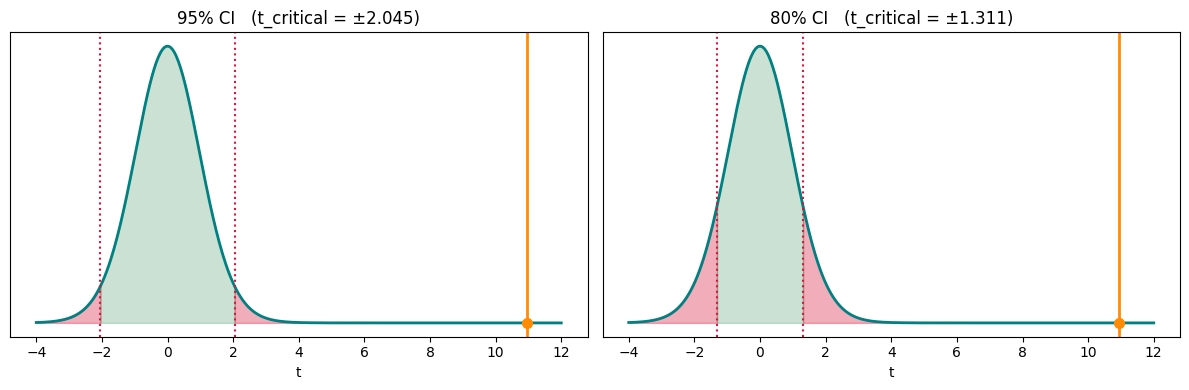

CI        alpha     t_critical    t_test    Decision
95% CI    0.05      2.0452        10.9545   Reject H0
80% CI    0.2       1.3114        10.9545   Reject H0


In [5]:
dfree = 29
t_test_val = 10.9545

alphas = {"95% CI": 0.05, "80% CI": 0.20}

x = np.linspace(-4, 12, 500)
y = st.t.pdf(x, dfree)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, (label, a) in zip(axes, alphas.items()):
    t_c = st.t.ppf(1 - a / 2, dfree)
    ax.plot(x, y, color="teal", linewidth=2)

    x_left = np.linspace(-4, -t_c, 100)
    x_right = np.linspace(t_c, 12, 100)
    ax.fill_between(x_left, st.t.pdf(x_left, dfree), color="crimson", alpha=0.35)
    ax.fill_between(x_right, st.t.pdf(x_right, dfree), color="crimson", alpha=0.35)

    x_mid = np.linspace(-t_c, t_c, 200)
    ax.fill_between(x_mid, st.t.pdf(x_mid, dfree), color="seagreen", alpha=0.25)

    ax.axvline(t_c, color="crimson", linestyle=":")
    ax.axvline(-t_c, color="crimson", linestyle=":")

    ax.axvline(t_test_val, color="darkorange", linewidth=2)
    ax.plot(t_test_val, st.t.pdf(t_test_val, dfree), "o", color="darkorange", markersize=7, zorder=5)

    ax.set_yticks([])
    ax.set_xlabel("t")
    ax.set_title(f"{label}   (t_critical = ±{t_c:.3f})")

plt.tight_layout()
plt.show()

print(f"{'CI':<10}{'alpha':<10}{'t_critical':<14}{'t_test':<10}{'Decision'}")
for label, a in alphas.items():
    t_c = st.t.ppf(1 - a / 2, dfree)
    decision = "Reject H0" if abs(t_test_val) > t_c else "Fail to reject H0"
    print(f"{label:<10}{a:<10}{t_c:<14.4f}{t_test_val:<10.4f}{decision}")

---

## FAQ

**1. Why does the critical value shrink from 2.045 (95% CI) to 1.311 (80% CI)?**

Confidence level and critical value move in the same direction. A **higher** CI (like 95%) demands stronger evidence before rejecting $H_0$, so it pushes the critical value further out into the tail (a wider acceptance region). A **lower** CI (like 80%) is more lenient — we're only asking for 80% confidence, so we accept a bigger risk of a Type I error ($\alpha = 0.20$ instead of $0.05$), which pulls the critical value inward (a narrower acceptance region, easier to spill into the rejection zone).

**2. Does the sample data ($\bar{x}, S, n$) change with the confidence level?**

No. $t_{test}$ is computed purely from what was observed — the sample mean, sample std, and sample size — none of which have anything to do with how confident we *choose* to be. Only $t_{critical}$ (Step 4) depends on $CI$. This is why $t_{test} \approx 10.96$ is identical in both the 95% and 80% CI versions of this notebook.

**3. If both CIs lead to "reject $H_0$," why bother computing both?**

Because it won't always be this clear-cut. Here, $t_{test} \approx 10.96$ is so extreme that it clears *both* thresholds easily — the medication's effect is obvious regardless of how strict we are. But in a borderline case (say $t_{test} = 1.5$), the 95% CI threshold (2.045) would say "fail to reject $H_0$," while the 80% CI threshold (1.311) would say "reject $H_0$" — the *same data* leading to *opposite conclusions* purely because of the confidence level chosen. That's exactly why $\alpha$/$CI$ must be picked **before** looking at the data, not adjusted afterward to get the answer you want.

**4. When would someone actually use an 80% CI instead of 95%?**

95% (or 99%) is the standard for most formal research, medicine, and any decision where a **false positive is costly** (e.g., wrongly approving a drug as effective). An 80% CI is more common in **exploratory or low-stakes** settings — e.g., early-stage screening, A/B tests where you're just looking for promising leads to investigate further, or internal business decisions where being wrong occasionally is cheap and moving fast matters more than rigor.

**5. How does this compare to the [95% CI version](12_Hypothesis_Testing_T-Test_95.ipynb) of this same problem?**

| | 95% CI | 80% CI |
|---|---|---|
| $\alpha$ | 0.05 | 0.20 |
| $\alpha/2$ (two-tailed) | 0.025 | 0.10 |
| $t_{critical}$ | $\pm 2.045$ | $\pm 1.311$ |
| $t_{test}$ | 10.96 | 10.96 |
| Decision | Reject $H_0$ | Reject $H_0$ |

Same hypotheses, same data, same $t_{test}$ — the only thing that moved is where the goalposts (critical value) sit.